In [20]:
import pandas as pd
import numpy as np
import joblib
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)
from category_encoders import TargetEncoder
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [21]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v2_feas.csv')

In [22]:
num_cols_to_fill = ['transaction_amount', 'time_day', 'time_diff_log']
for col in num_cols_to_fill:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

cat_cols_to_fill = [col for col in df.columns if col not in num_cols_to_fill]
for col in cat_cols_to_fill:
    df[col] = df[col].astype(str)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   is_fraud                 588912 non-null  object 
 1   transaction_amount       588912 non-null  float64
 2   card_type                588912 non-null  object 
 3   purchaser_email_domain   588912 non-null  object 
 4   device_type              588912 non-null  object 
 5   is_identity_seen_before  588912 non-null  object 
 6   user_os                  588912 non-null  object 
 7   user_browser             588912 non-null  object 
 8   environment_risk         588912 non-null  object 
 9   card_info                588912 non-null  object 
 10  time_hour                588912 non-null  object 
 11  time_day                 588912 non-null  float64
 12  amt_bins                 588912 non-null  object 
 13  day_of_week              588912 non-null  object 
 14  time

In [24]:
df = df.drop(columns=['transaction_amount', 'time_day'], axis=1)

In [25]:
main = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Fraud_Data.csv')
v4 = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/model_v4.csv')
df['amt_log'] = v4['amt_log']
df['time_diff_bins'] = pd.cut(df['time_diff_log'], bins=20, include_lowest=True).astype(object)
df['card_type_user_os'] = v4['card_type_user_os']
df['card_network'] = main['card_network']

In [26]:
label = df['is_fraud'].astype(int)
predictors = df.drop(columns=['is_fraud'])
x_train, x_test, y_train, y_test = train_test_split(
    predictors, label, test_size=0.2, random_state=42, stratify=label
)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)
print(y_train.value_counts(normalize=True))

is_fraud
0    0.964982
1    0.035018
Name: proportion, dtype: float64


In [27]:
num_cols    = ['amt_log', 'time_diff_log']
target_cols = ['purchaser_email_domain']
cat_cols    = [col for col in x_train.columns if col not in num_cols + target_cols]

In [28]:
# cat_pipeline = Pipeline([
#     ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])
# target_pipeline = Pipeline([
#     ('target', TargetEncoder(smoothing=10, handle_unknown='value'))
# ])
# preprocessor = ColumnTransformer([
#     ('num',    'passthrough',   num_cols),
#     ('target', target_pipeline, target_cols),
#     ('cat',    cat_pipeline,    cat_cols)
# ])

# neg = int((y_train == 0).sum())
# pos = int((y_train == 1).sum())
# print(f"neg={neg:,}  pos={pos:,}  ratio={neg/pos:.1f}")

# model = LGBMClassifier(
#     n_estimators      = 500,
#     learning_rate     = 0.05,
#     max_depth         = 7,
#     min_child_samples = 20,
#     subsample         = 0.8,
#     colsample_bytree  = 0.8,
#     scale_pos_weight  = neg / pos,   # handles imbalance
#     random_state      = 42,
#     n_jobs            = -1,
#     verbose           = -1
# )

# final_pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', model)
# ])
# print("Pipeline ready ✓")

In [29]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cv_predict = cross_val_predict(final_pipe, x_train, y_train, cv=cv, n_jobs=-1)
# joblib.dump(cv_predict, 'cv_predict_lgbm.pkl')
# print("cv_predict saved ✓", cv_predict.shape)

# cv_proba = cross_val_predict(final_pipe, x_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
# joblib.dump(cv_proba, 'cv_proba_lgbm.pkl')
# print("cv_proba saved ✓", cv_proba.shape)

In [30]:
# final_pipe.fit(x_train, y_train)
# joblib.dump(final_pipe, 'model_lgbm.pkl')
# print("Model saved ✓")

In [31]:
model = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/model_4_lgb.pkl')
cv_predict = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_predict_4_lgb.pkl')
cv_proba = joblib.load('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Models/cv_proba_4_lgb.pkl')

In [32]:
print(f"Precision : {precision_score(y_train, cv_predict) * 100:.2f}%")
print(f"Recall    : {recall_score(y_train, cv_predict) * 100:.2f}%")
print()
print(classification_report(y_train, cv_predict))

Precision : 12.19%
Recall    : 60.14%

              precision    recall  f1-score   support

           0       0.98      0.84      0.91    454631
           1       0.12      0.60      0.20     16498

    accuracy                           0.83    471129
   macro avg       0.55      0.72      0.56    471129
weighted avg       0.95      0.83      0.88    471129



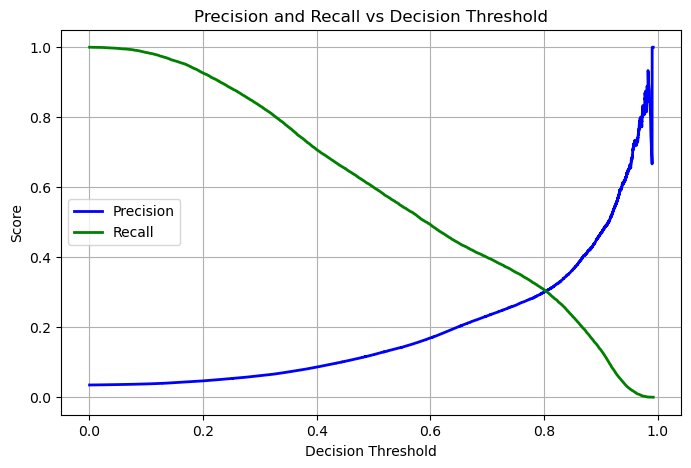

In [33]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_train, cv_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_vals[:-1], 'b-', linewidth=2, label='Precision')
plt.plot(thresholds, recall_vals[:-1],   'g-', linewidth=2, label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
fraud_probs = model.predict_proba(x_train)[y_train == 1, 1]
print('fraud_porbs done')
nonfraud_probs = model.predict_proba(x_train)[y_train == 0, 1]
print('fraud_porbs done')

fraud_porbs done
fraud_porbs done


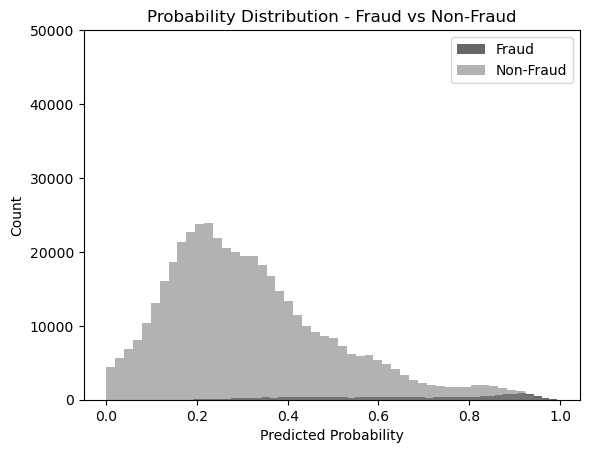

In [36]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
plt.ylim(0, 50000)
plt.show()

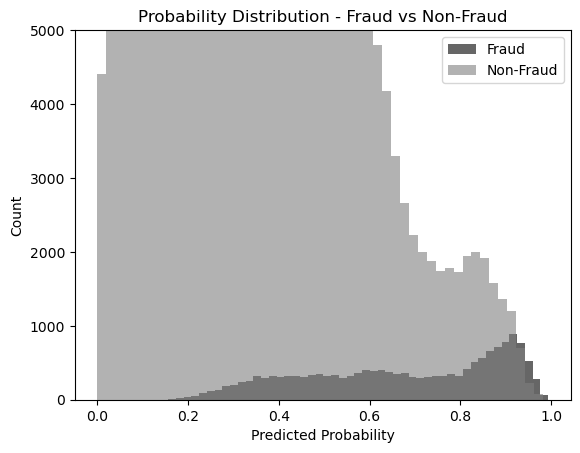

In [37]:
plt.hist(fraud_probs, bins=50, alpha=0.6, label='Fraud', color='black')
plt.hist(nonfraud_probs, bins=50, alpha=0.6, label='Non-Fraud', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Fraud vs Non-Fraud')
plt.legend()
plt.ylim(0, 5000)
plt.show()

In [40]:
print(f"Fraud Mean:      {fraud_probs.mean():.4f}")
print(f"Non-Fraud Mean:  {nonfraud_probs.mean():.4f}")
print(f"Gap:             {(fraud_probs.mean() - nonfraud_probs.mean()):.4f}")
print(f"Fraud Max:       {fraud_probs.max():.4f}")
print(f"Non Fraud min: {nonfraud_probs.min():.4f}")
print(f"Fraud Std:         {fraud_probs.std():.4f}")
print(f"Non-Fraud Std:     {nonfraud_probs.std():.4f}")

Fraud Mean:      0.6722
Non-Fraud Mean:  0.3185
Gap:             0.3537
Fraud Max:       0.9936
Non Fraud min: 0.0001
Fraud Std:         0.2122
Non-Fraud Std:     0.1854


In [39]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 471129 entries, 523036 to 88530
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   card_type                471129 non-null  object 
 1   purchaser_email_domain   471129 non-null  object 
 2   device_type              471129 non-null  object 
 3   is_identity_seen_before  471129 non-null  object 
 4   user_os                  471129 non-null  object 
 5   user_browser             471129 non-null  object 
 6   environment_risk         471129 non-null  object 
 7   card_info                471129 non-null  object 
 8   time_hour                471129 non-null  object 
 9   amt_bins                 471129 non-null  object 
 10  day_of_week              471129 non-null  object 
 11  time_diff_log            471129 non-null  float64
 12  amt_log                  471129 non-null  float64
 13  time_diff_bins           471129 non-null  object 
 14  card_